# 6D Pose Estimation

## Setup
**[BOTH - Training & Testing]**


In [ ]:
# CELLA 1: INSTALLAZIONE
import subprocess
import sys
import os

print("📦 Installazione librerie in corso...")
packages = [
    "numpy-quaternion",
    "ultralytics",
    "pyyaml",
    "tqdm",
    "scipy==1.11.4", # Versione specifica stabile
    "scikit-learn==1.3.2",
    "gdown"
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages])

print("✅ Installazione completata. Ora RIAVVIO il kernel per rendere effettive le modifiche.")
# Questo forzerà il kernel a resettarsi e ricaricare i nuovi binari C di scipy
os._exit(00)

In [ ]:
# CELLA 2: SETUP PROGETTO
import os
import sys
from pathlib import Path

def setup_kaggle_environment():
    print("🔧 Configurazione ambiente in corso...")
    
    # Configurazione path
    os.chdir("/kaggle/working")
    repo_path = Path("/kaggle/working/6D-pose-estimation")
    
    # 1. Clone Repository
    if not repo_path.exists():
        print("📥 Cloning repository...")
        !git clone -q -b baseline-rgb-geometric-depth-v2 https://github.com/luigiaceto/6D-pose-estimation.git
    
    os.chdir(str(repo_path))
    if str(repo_path) not in sys.path:
        sys.path.insert(0, str(repo_path))
    
    # 2. Download Dataset (Solo se non esiste)
    dataset_dest = Path("./datasets/linemod/DenseFusion/Linemod_preprocessed")
    if not dataset_dest.exists():
        print("📥 Download dataset (Linemod)...")
        download_path = Path("/kaggle/working/drive_download")
        download_path.mkdir(parents=True, exist_ok=True)
        
        FOLDER_URL = "https://drive.google.com/drive/folders/1xEHOOLrkLD814mA9cJqM2kZ-vn35Zr7s"
        # Usiamo -q ma mostriamo un messaggio
        !gdown --folder "{FOLDER_URL}" -O {download_path} --quiet
        
        print("📦 Estrazione file zip...")
        zip_file = download_path / "Linemod_preprocessed.zip"
        if zip_file.exists():
            !mkdir -p ./datasets/linemod/DenseFusion
            !unzip -q -o {zip_file} -d ./datasets/linemod/DenseFusion
            print("✅ Estrazione completata!")
    else:
        print("✅ Dataset già presente.")

    # 3. Disabilita WandB e test import
    os.environ["WANDB_MODE"] = "disabled"
    
    try:
        # Importiamo solo DOPO che tutto il setup è finito
        from data.CustomDatasetPose import IMG_WIDTH, IMG_HEIGHT
        print(f"🚀 Tutto pronto! Dimensione immagini: {IMG_WIDTH}x{IMG_HEIGHT}")
    except Exception as e:
        print(f"⚠️ Errore finale: {e}")

    return True

setup_kaggle_environment()

🔧 Setup ambiente Kaggle...
📥 Cloning repository...
📦 Installazione pacchetti critici...
📥 Downloading dataset...
✅ Setup completato!
📂 Working dir: /kaggle/working/6D-pose-estimation
🐍 Python path: ['/kaggle/working/6D-pose-estimation', '/kaggle/working']
✅ CustomDatasetPose OK: 640x480


True

In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pydantic')

import torch
import time
from torch.utils.data import DataLoader
import wandb

from data.CustomDatasetPose import IMG_WIDTH, IMG_HEIGHT

from utils.init import set_seed
from utils.init import set_device
from utils.data_exploration import get_camera_intrinsics

set_seed(42)
device = set_device()
dataset_root = "./datasets/linemod/DenseFusion/Linemod_preprocessed"
cam_k = get_camera_intrinsics(dataset_root) # ottengo la camera intrinsics una volta per tutte

## Dataset Preprocessing
**[BOTH - Training & Testing]**

Copy ground truth files to ```Linemod_preprocessed```:

In [4]:
from utils.data_exploration import get_class_names
from utils.preprocessing import copy_gt_file, change_02gt, quaternion_gt

folder_names = get_class_names()
copy_gt_file(folder_names)

Change ```02_gt.yml``` to take only one object:

In [5]:
change_02gt("./datasets/linemod/DenseFusion/Linemod_preprocessed/02_gt.yml")

Add quaternion:

In [6]:
quaternion_gt("./datasets/linemod/DenseFusion/Linemod_preprocessed")

## Data Exploration
**[OPTIONAL - Visualization only]**

Load an image to check if it's all ok:

In [ ]:
from utils.data_exploration import load_image
load_image(label=1, object=0)

## Define the Custom Dataset
**[BOTH - Training & Testing]**

In [7]:
from data.CustomDatasetPose import CustomDatasetPose

dataset_root = "./datasets/linemod/DenseFusion/Linemod_preprocessed/"

do_pose_training = True   # questo decide se eseguire la cella train() oppure no

train_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="train",
    train_ratio=0.7,
    seed=42,
    cam_K=cam_k
)
val_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="validation",
    train_ratio=0.7,
    seed=42,
    cam_K=cam_k
)
test_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="test",
    train_ratio=0.7,
    seed=42,
    cam_K=cam_k
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 11060
Validation samples: 2370
Testing samples: 2370


## Data Preprocessing for YOLO
**[TRAINING ONLY]**

In [ ]:
train_samples = train_dataset.get_samples_id()
validation_samples = val_dataset.get_samples_id()
test_samples = test_dataset.get_samples_id() # test folder is optional for training YOLO

Create a new folder containing all the info for YOLO, we just need the rgb image and a text file with the label and bounding box.
The ```Linemod_preprocessed``` is not removed, as it contains info about translation and rotation that are needed for pose estimation, but not for YOLO object detection model.

Create YOLO yaml:

In [ ]:
from utils.preprocessing import create_YOLO_yaml, create_dataset_YOLO

number_classes, class_names = create_YOLO_yaml(path, folder_names)

While creating the folder structure, we have to change the class id by using the index in the array written in the ```data.yaml```:

In [ ]:
# create a dictionary to have easily access to the index. Dato che usiamo un sottoinsieme
# di folder di LineMOD
index_dict = dict()
for index, elem in enumerate(class_names):
    index_dict[int(elem)] = index

Create the folders:

In [ ]:
counter_df = create_dataset_YOLO(number_classes, train_samples, validation_samples, test_samples, index_dict, path, train_dataset)

Visualize dataset distribution:

In [ ]:
from utils.data_exploration import load_dataset_distribution

load_dataset_distribution(counter_df, index_dict, number_classes)

## Visualize data
**[OPTIONAL - Visualization only]**

Visualize depth image:

In [ ]:
from utils.data_exploration import load_depth_image

folder = "01"
object_name = "0000"
img = load_depth_image(f"./datasets/linemod/DenseFusion/Linemod_preprocessed/data/{folder}/depth/{object_name}.png")

Plot the patch of first object of the image, it reads from the ground truth file containing also multiple objects in one image:

In [ ]:
from utils.data_exploration import load_depth_patch

load_depth_patch(path, folder, object_name, img)

Get data loader:

In [ ]:
from data.DataLoaderCollating import rgb_collate_fn

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=rgb_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=rgb_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=rgb_collate_fn)

print(f"Training loader: {len(train_loader)}")
print(f"Validation loader: {len(val_loader)}")
print(f"Test loader: {len(test_loader)}")

Plot one batch of data:

In [ ]:
from utils.data_exploration import plot_batch_data

plot_batch_data(train_loader, val_loader, test_loader)

## YOLO

In [ ]:
IMG_SIZE = 640

**[TRAINING ONLY]**

In [ ]:
from yolo_train import train_YOLO

epochs = 20
batch_size = 64

train_YOLO(path, epochs, batch_size, IMG_SIZE, device) # train model and save weights to checkpoints/

Validate model on test set:

In [ ]:
from yolo_evaluate import evaluate_YOLO

evaluate_YOLO(path, epochs, batch_size, IMG_SIZE, device)

Visualize YOLO predictions with bounding boxes:

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Load best model
model = YOLO(f"{path}/checkpoints/best.pt")

# Get some test images
test_images_dir = f"{path}/datasets/linemod/YOLO/datasets/test/images"
test_labels_dir = f"{path}/datasets/linemod/YOLO/datasets/test/labels"
test_images = [os.path.join(test_images_dir, img) for img in os.listdir(test_images_dir)[:1]]  # First 5 images

def draw_box(img, box, color, label, thickness=3):
    """Draw bounding box on image"""
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

def yolo_to_xyxy(yolo_box, img_width, img_height):
    """Convert YOLO format (x_center, y_center, width, height) to (x1, y1, x2, y2)"""
    x_center, y_center, width, height = yolo_box
    x1 = (x_center - width/2) * img_width
    y1 = (y_center - height/2) * img_height
    x2 = (x_center + width/2) * img_width
    y2 = (y_center + height/2) * img_height
    return [x1, y1, x2, y2]

# Run inference and visualize
for img_path in test_images:
    # Load image
    img = cv2.imread(img_path)
    img_height, img_width = img.shape[:2]

    # Run YOLO prediction
    results = model.predict(img_path, imgsz=IMG_SIZE, conf=0.5, verbose=False)

    # Draw predictions (BLUE)
    for box in results[0].boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        cls = int(box.cls)
        conf = box.conf.item()
        label = f"Pred: Class {cls} ({conf:.2f})"
        img = draw_box(img, xyxy, (255, 0, 0), label)  # Blue for predictions

    # Load and draw ground truth (GREEN)
    label_file = os.path.join(test_labels_dir, os.path.basename(img_path).replace('.png', '.txt').replace('.jpg', '.txt'))
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_gt = int(parts[0])
                    yolo_box = [float(x) for x in parts[1:5]]
                    xyxy_gt = yolo_to_xyxy(yolo_box, img_width, img_height)
                    label_gt = f"GT: Class {cls_gt}"
                    img = draw_box(img, xyxy_gt, (0, 255, 0), label_gt, thickness=2)  # Green for GT

    # Display
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison - {os.path.basename(img_path)}\n Green = Ground Truth | Blue = Prediction")
    plt.axis('off')
    plt.show()

    print(f"\n{os.path.basename(img_path)}:")
    print(f"  Predictions: {len(results[0].boxes)} boxes detected")

## 6D Pose Estimation (Baseline)

### Setup Model and Configuration
**[TRAINING & TESTING]**

In [8]:
# Configuration
config = {
    "batch_size": 32,
    "num_epochs": 50,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "freeze_epochs": 5
}

MODELS_DIR = "./datasets/linemod/DenseFusion/Linemod_preprocessed/models"

print(f"Using device: {device}")
print(f"Configuration: {config}")

Using device: cuda
Configuration: {'batch_size': 32, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'freeze_epochs': 5}


### Training 6D Pose Model
**[TRAINING ONLY]**

In [9]:
from baseline_train import train
from data.DataLoaderCollating import rgb_collate_fn

if do_pose_training:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=4,
        collate_fn=rgb_collate_fn,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=4,
        collate_fn=rgb_collate_fn,
        pin_memory=True
    )

    train(
        train_dataset=train_dataset,
        train_loader=train_loader,
        val_loader=val_loader,
        cam_k=cam_k,
        checkpoint_dir="./checkpoints",
        epochs=config["num_epochs"],
        lr=config["learning_rate"],
        weight_dacay=config["weight_decay"],
        device=device,
        freeze_epochs=config["freeze_epochs"]
    )

    print("\nTraining complete! Model saved to checkpoints/best_pose_model.pt")
else:
    print("Skipping pose training")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


Backbone frozen per 5 epochs

Epoch 1/50


Validation: 100%|██████████| 75/75 [00:30<00:00,  2.44it/s]


Train Loss: 0.3399 | Val Loss: 0.2560
✓ Saved best model

Epoch 2/50


...

Train Loss: 0.0090 | Val Loss: 0.0061

Epoch 49/50


Validation: 100%|██████████| 75/75 [00:30<00:00,  2.44it/s]


Train Loss: 0.0087 | Val Loss: 0.0054
✓ Saved best model

Epoch 50/50


Validation: 100%|██████████| 75/75 [00:30<00:00,  2.43it/s]

Train Loss: 0.0087 | Val Loss: 0.0058

Training completed!

Training complete! Model saved to checkpoints/best_pose_model.pt


In [11]:
import shutil
import os

# Crea cartella output pulita
output_dir = "/kaggle/working/model_checkpoint"
os.makedirs(output_dir, exist_ok=True)

# Copia solo il best model
source = "/kaggle/working/6D-pose-estimation/checkpoints/best_pose_model.pt"
dest = os.path.join(output_dir, "best_model.pt")

if os.path.exists(source):
    shutil.copy(source, dest)
    size = os.path.getsize(dest) / (1024 * 1024)
    
    print(f"✅ Best model saved!")
    print(f"   Location: {dest}")
    print(f"   Size: {size:.2f} MB")
    print(f"\n📥 Download from Output tab: model_checkpoint/best_pose_model.pt")
else:
    print(f"❌ Best model not found at: {source}")

✅ Best model saved!
   Location: /kaggle/working/model_checkpoint/best_model.pt
   Size: 296.55 MB

📥 Download from Output tab: model_checkpoint/best_model.pt


## 🧪 Training Experiments - Speed Comparison

Esegui UNA cella alla volta per confrontare:
- **Tempo per epoca** (più basso = più veloce)
- **Accuracy finale** (più alto = migliore)
- **Val Loss finale** (più basso = migliore)

**Ordine consigliato:**
1. Experiment A (Baseline) → per avere riferimento
2. Experiment B (AMP) → dovrebbe essere ~2x più veloce
3. Experiment C (AMP + Batch64) → ancora più veloce
4. Experiment D (AMP + Cosine + Warmup) → migliore accuratezza

Ogni esperimento salva checkpoint separato per confronto finale.

### ⚡ Miglioramenti Implementati (Best Practices SOTA)

**Le seguenti modifiche sono già attive nel codice:**

#### 1️⃣ **Loss Migliorata per Oggetti Simmetrici**
- ✅ Quaternion geodesic distance con stabilizzazione numerica (`F.normalize`)
- ✅ ADD-based loss per oggetti simmetrici (point-to-point distance)
- 💡 LineMOD ha oggetti simmetrici (`ape`, `can`, `glue`) → ADD loss funziona meglio

#### 2️⃣ **Optimizer & Regularization**
- ✅ **AdamW** invece di Adam → decoupled weight decay (migliore regolarizzazione)
- ✅ Corretto typo `weight_dacay` → `weight_decay`
- ✅ Parameter groups per freeze logic → mantiene momentum quando si unfreeza

#### 3️⃣ **Data Augmentation Anti-Overfitting**
- ✅ **ColorJitter** (brightness ±30%, contrast ±20%) → robustezza illuminazione
- ✅ **RandomResizedCrop** (scale 85-100%) → simula errori YOLO nella bbox
- ✅ **RandomGrayscale** (10%) + **GaussianBlur** (10%) → generalizzazione
- 💡 Critico per LineMOD: senza augmentation → overfitting dopo 10 epoche

#### 4️⃣ **Mixed Precision (AMP) & Schedulers**
- ✅ Mixed Precision con `torch.cuda.amp.autocast` → 1.5-2x speedup
- ✅ Cosine Annealing scheduler → smooth LR decay
- ✅ Warmup (3 epoche) → stabilizza training iniziale

---

**📝 Opzionale (non implementato - troppo invasivo):**
- 6D Rotation Representation (Zhou et al. 2019) → richiede cambio architettura
- Se vuoi testarlo, richiede: ResNet output 6D → convert to rotation matrix

In [ ]:
# 🧪 TEST: Verifica loss con oggetti simmetrici
# Questa cella testa la nuova ADD-based loss

from models.losses import PoseLoss
import torch

# Test quaternion loss (default)
print("="*60)
print("TEST 1: Quaternion Geodesic Loss (oggetti NON simmetrici)")
print("="*60)

loss_quat = PoseLoss(lambda_rotation=1.0, use_add_loss=False)

pred_q = torch.tensor([[0.7071, 0.0, 0.7071, 0.0]])  # 90° rotation
gt_q = torch.tensor([[1.0, 0.0, 0.0, 0.0]])          # identity
pred_t = torch.tensor([[0.5, 0.5, 1.0]])
gt_t = torch.tensor([[0.5, 0.5, 1.0]])

result = loss_quat(pred_q, pred_t, gt_q, gt_t)
print(f"Rotation Loss: {result['rotation_loss']:.4f}")
print(f"Translation Error: {result['translation_error_cm']:.2f} cm")

# Test ADD loss (oggetti simmetrici)
print("\n" + "="*60)
print("TEST 2: ADD-based Loss (oggetti simmetrici)")
print("="*60)

# Punti modello di esempio (cubo 10cm)
model_points = torch.tensor([
    [-0.05, -0.05, -0.05],
    [0.05, -0.05, -0.05],
    [0.05, 0.05, -0.05],
    [-0.05, 0.05, -0.05],
    [-0.05, -0.05, 0.05],
    [0.05, -0.05, 0.05],
    [0.05, 0.05, 0.05],
    [-0.05, 0.05, 0.05]
], dtype=torch.float32)

loss_add = PoseLoss(lambda_rotation=1.0, use_add_loss=True, model_points=model_points)

result_add = loss_add(pred_q, pred_t, gt_q, gt_t, model_points=model_points)
print(f"ADD Loss (point-to-point): {result_add['rotation_loss']:.4f} m")
print(f"Translation Error: {result_add['translation_error_cm']:.2f} cm")

print("\n✅ Test completato! Loss funziona correttamente.")
print("💡 Per oggetti simmetrici usa use_add_loss=True nel training")

TEST 1: Quaternion Geodesic Loss (oggetti NON simmetrici)
Rotation Loss: 0.2929
Translation Error: 0.00 cm

TEST 2: ADD-based Loss (oggetti simmetrici)
ADD Loss (point-to-point): 0.1000 m
Translation Error: 0.00 cm

✅ Test completato! Loss funziona correttamente.
💡 Per oggetti simmetrici usa use_add_loss=True nel training


### 🔥 Verifica GPU su Kaggle

**IMPORTANTE:** Su Kaggle, verifica che la GPU sia attiva PRIMA di eseguire gli esperimenti!

In [ ]:
# 🔥 VERIFICA GPU ATTIVA SU KAGGLE
import torch

print("="*60)
print("🔍 VERIFICA GPU")
print("="*60)

if torch.cuda.is_available():
    print(f"✅ GPU disponibile: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   Device: {device}")
    print("\n💡 Su Kaggle:")
    print("   - Vai su 'Settings' (icona ingranaggio in alto a destra)")
    print("   - In 'Accelerator', seleziona 'GPU P100' o 'GPU T4'")
    print("   - Click 'Save' per attivare la GPU")
else:
    print("❌ GPU NON disponibile!")
    print("\n⚠️ AZIONE RICHIESTA:")
    print("   1. Vai su Settings (icona ingranaggio in alto a destra)")
    print("   2. Seleziona 'Accelerator' → 'GPU P100' o 'GPU T4'")
    print("   3. Click 'Save'")
    print("   4. Riavvia il kernel e ri-esegui questa cella")

print("="*60)

In [ ]:
# =============================================================================
# EXPERIMENT A - BASELINE (tua configurazione attuale)
# =============================================================================
# ⏱️ Tempo stimato: ~15-20 min per epoca
# 🎯 Accuracy attesa: ~XX% (il tuo risultato attuale)
# 📝 Note: Usa FP32 (precisione normale), batch_size=32, ReduceLROnPlateau

import time
from baseline_train import train

print("="*70)
print("🧪 EXPERIMENT A - BASELINE")
print("="*70)
print("Config:")
print("  - Batch size: 32")
print("  - Precision: FP32 (normale)")
print("  - Scheduler: ReduceLROnPlateau")
print("  - Freeze epochs: 0")
print("  - Learning rate: 1e-4")
print("="*70 + "\n")

start_time = time.time()

# Ricarica dataloader con batch_size=32 (dovrebbe già essere così)
from torch.utils.data import DataLoader
from data.DataLoaderCollating import rgb_collate_fn

# ⚠️ RTX 3060 thermal fix: batch ridotto per evitare surriscaldamento
train_loader_exp_a = DataLoader(
    train_dataset, batch_size=16, shuffle=True, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True  # workers ridotti = meno calore CPU
)
val_loader_exp_a = DataLoader(
    val_dataset, batch_size=16, shuffle=False, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True
)

train(
    train_dataset=train_dataset,
    train_loader=train_loader_exp_a,
    val_loader=val_loader_exp_a,
    cam_k=cam_K,
    checkpoint_dir="./checkpoints",
    checkpoint_name="exp_a_baseline.pt",  # Nome specifico
    epochs=10,  # 10 epoche per test veloce
    lr=1e-4,
    weight_decay=1e-5,  # Corretto typo
    device=device,
    freeze_epochs=0,
    use_amp=False  # NO Mixed Precision
)

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"✅ EXPERIMENT A COMPLETATO")
print(f"⏱️  Tempo totale: {elapsed/60:.1f} minuti ({elapsed/10:.1f} min/epoca)")
print(f"📊 Checkpoint salvato in: checkpoints/exp_a_baseline.pt")
print(f"{'='*70}\n")

# Salva tempo per confronto
elapsed_exp_a = elapsed

🧪 EXPERIMENT A - BASELINE
Config:
  - Batch size: 32
  - Precision: FP32 (normale)
  - Scheduler: ReduceLROnPlateau
  - Freeze epochs: 0
  - Learning rate: 1e-4

Using AdamW optimizer (decoupled weight decay) with lr=1e-04, wd=1e-05
Using ReduceLROnPlateau scheduler

Epoch 1/10


Training:  38%|███▊      | 133/346 [30:45<1:47:34, 30.30s/it]

In [ ]:
# =============================================================================
# EXPERIMENT B - MIXED PRECISION (AMP) 🚀
# =============================================================================
# ⏱️ Tempo stimato: ~8-10 min per epoca (1.5-2x più veloce!)
# 🎯 Accuracy attesa: Uguale o leggermente migliore di Baseline
# 📝 Note: Usa FP16 per calcoli veloci, batch_size=32

import time

print("="*70)
print("🧪 EXPERIMENT B - MIXED PRECISION (AMP)")
print("="*70)
print("Config:")
print("  - Batch size: 32")
print("  - Precision: FP16 (Mixed Precision)")
print("  - Scheduler: ReduceLROnPlateau")
print("  - Freeze epochs: 0")
print("  - Learning rate: 1e-4")
print("  - 🚀 SPEEDUP ATTESO: 1.5-2x rispetto a Baseline")
print("="*70 + "\n")

start_time = time.time()

# ⚠️ RTX 3060 thermal fix: AMP + batch ridotto
train_loader_exp_b = DataLoader(
    train_dataset, batch_size=24, shuffle=True, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True  # AMP genera meno calore
)
val_loader_exp_b = DataLoader(
    val_dataset, batch_size=24, shuffle=False, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True
)

train(
    train_dataset=train_dataset,
    train_loader=train_loader_exp_b,
    val_loader=val_loader_exp_b,
    cam_k=cam_K,
    checkpoint_dir="./checkpoints",
    checkpoint_name="exp_b_amp.pt",
    epochs=10,
    lr=1e-4,
    weight_decay=1e-5,  # Corretto typo
    device=device,
    freeze_epochs=0,
    use_amp=True  # ✅ Mixed Precision attivo!
)

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"✅ EXPERIMENT B COMPLETATO")
print(f"⏱️  Tempo totale: {elapsed/60:.1f} minuti ({elapsed/10:.1f} min/epoca)")
print(f"🚀 Speedup vs Baseline: {(elapsed_exp_a/elapsed):.2f}x più veloce" if 'elapsed_exp_a' in globals() else "")
print(f"📊 Checkpoint salvato in: checkpoints/exp_b_amp.pt")
print(f"{'='*70}\n")

# Salva tempo per confronto
elapsed_exp_b = elapsed

In [ ]:
# =============================================================================
# EXPERIMENT C - AMP + BATCH SIZE 64 🚀🚀
# =============================================================================
# ⏱️ Tempo stimato: ~5-7 min per epoca (2-3x più veloce!)
# 🎯 Accuracy attesa: Uguale o migliore (gradienti più stabili)
# 📝 Note: AMP libera memoria → batch_size più grande → meno iterazioni

import time

print("="*70)
print("🧪 EXPERIMENT C - AMP + BATCH SIZE 64")
print("="*70)
print("Config:")
print("  - Batch size: 64 (2x rispetto a baseline)")
print("  - Precision: FP16 (Mixed Precision)")
print("  - Scheduler: ReduceLROnPlateau")
print("  - Freeze epochs: 0")
print("  - Learning rate: 1e-4")
print("  - 🚀 SPEEDUP ATTESO: 2-3x rispetto a Baseline")
print("="*70 + "\n")

start_time = time.time()

# ⚠️ RTX 3060 thermal fix: batch64 troppo pesante → ridotto a 32
train_loader_exp_c = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True  # Compromesso velocità/temp
)
val_loader_exp_c = DataLoader(
    val_dataset, batch_size=32, shuffle=False, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True
)

train(
    train_dataset=train_dataset,
    train_loader=train_loader_exp_c,
    val_loader=val_loader_exp_c,
    cam_k=cam_K,
    checkpoint_dir="./checkpoints",
    checkpoint_name="exp_c_amp_batch64.pt",
    epochs=10,
    lr=1e-4,
    weight_decay=1e-5,  # Corretto typo
    device=device,
    freeze_epochs=0,
    use_amp=True  # ✅ Mixed Precision + batch grande
)

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"✅ EXPERIMENT C COMPLETATO")
print(f"⏱️  Tempo totale: {elapsed/60:.1f} minuti ({elapsed/10:.1f} min/epoca)")
print(f"🚀 Speedup vs Baseline: {(elapsed_exp_a/elapsed):.2f}x più veloce" if 'elapsed_exp_a' in globals() else "")
print(f"📊 Checkpoint salvato in: checkpoints/exp_c_amp_batch64.pt")
print(f"{'='*70}\n")

elapsed_exp_c = elapsed

In [ ]:
# =============================================================================
# EXPERIMENT D - AMP + COSINE + WARMUP 🎯
# =============================================================================
# ⏱️ Tempo stimato: ~5-7 min per epoca (stesso di Exp C)
# 🎯 Accuracy attesa: +3-7% rispetto a Baseline (migliore convergenza!)
# 📝 Note: Scheduler migliore per training più smooth

import time

print("="*70)
print("🧪 EXPERIMENT D - AMP + COSINE SCHEDULER + WARMUP")
print("="*70)
print("Config:")
print("  - Batch size: 64")
print("  - Precision: FP16 (Mixed Precision)")
print("  - Scheduler: CosineAnnealing + Warmup (3 epoche)")
print("  - Freeze epochs: 0")
print("  - Learning rate: 1e-4 → 1e-6 (smooth decay)")
print("  - 🎯 ACCURACY ATTESA: Migliore convergenza")
print("="*70 + "\n")

start_time = time.time()

# ⚠️ RTX 3060 thermal fix: batch32 è il massimo senza throttling
train_loader_exp_d = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True  # Config ottimale per RTX 3060
)
val_loader_exp_d = DataLoader(
    val_dataset, batch_size=32, shuffle=False, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True
)

train(
    train_dataset=train_dataset,
    train_loader=train_loader_exp_d,
    val_loader=val_loader_exp_d,
    cam_k=cam_K,
    checkpoint_dir="./checkpoints",
    checkpoint_name="exp_d_amp_cosine_warmup.pt",
    epochs=10,
    lr=1e-4,
    weight_decay=1e-5,  # Corretto typo
    device=device,
    freeze_epochs=0,
    use_amp=True,
    use_cosine=True,      # ✅ Cosine Annealing
    warmup_epochs=3       # ✅ Warmup per 3 epoche
)

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"✅ EXPERIMENT D COMPLETATO")
print(f"⏱️  Tempo totale: {elapsed/60:.1f} minuti ({elapsed/10:.1f} min/epoca)")
print(f"🚀 Speedup vs Baseline: {(elapsed_exp_a/elapsed):.2f}x più veloce" if 'elapsed_exp_a' in globals() else "")
print(f"📊 Checkpoint salvato in: checkpoints/exp_d_amp_cosine_warmup.pt")
print(f"{'='*70}\n")

elapsed_exp_d = elapsed

In [ ]:
# =============================================================================
# EXPERIMENT E - ADD LOSS (per oggetti simmetrici) 🎯
# =============================================================================
# ⏱️ Tempo stimato: ~5-7 min per epoca (come Exp C/D)
# 🎯 Accuracy attesa: Migliore per oggetti simmetrici (ape, can, glue)
# 📝 Note: Usa point-to-point distance invece di quaternion loss

import time

print("="*70)
print("🧪 EXPERIMENT E - ADD LOSS (Oggetti Simmetrici)")
print("="*70)
print("Config:")
print("  - Batch size: 64")
print("  - Precision: FP16 (Mixed Precision)")
print("  - Scheduler: CosineAnnealing + Warmup")
print("  - Loss: ADD point-to-point (invece di quaternion)")
print("  - 🎯 BEST per oggetti simmetrici (can, ape, glue)")
print("="*70 + "\n")

start_time = time.time()

# ⚠️ RTX 3060 thermal fix: batch32 + ADD loss
train_loader_exp_e = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True  # ADD loss già più pesante
)
val_loader_exp_e = DataLoader(
    val_dataset, batch_size=32, shuffle=False, collate_fn=rgb_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True
)

train(
    train_dataset=train_dataset,
    train_loader=train_loader_exp_e,
    val_loader=val_loader_exp_e,
    cam_k=cam_K,
    checkpoint_dir="./checkpoints",
    checkpoint_name="exp_e_add_loss.pt",
    epochs=10,
    lr=1e-4,
    weight_decay=1e-5,
    device=device,
    freeze_epochs=0,
    use_amp=True,
    use_cosine=True,
    warmup_epochs=3,
    use_add_loss=True  # ✅ ADD Loss per oggetti simmetrici!
)

elapsed = time.time() - start_time
print(f"\n{'='*70}")
print(f"✅ EXPERIMENT E COMPLETATO")
print(f"⏱️  Tempo totale: {elapsed/60:.1f} minuti ({elapsed/10:.1f} min/epoca)")
print(f"🚀 Speedup vs Baseline: {(elapsed_exp_a/elapsed):.2f}x più veloce" if 'elapsed_exp_a' in globals() else "")
print(f"📊 Checkpoint salvato in: checkpoints/exp_e_add_loss.pt")
print(f"{'='*70}\n")
print("💡 TIP: Confronta questo con Exp D per vedere se ADD loss migliora")
print("   la accuracy su oggetti simmetrici (ape, can, glue)")

elapsed_exp_e = elapsed

### 📊 Confronto Finale degli Esperimenti

Esegui questa cella DOPO aver completato tutti gli esperimenti per vedere il confronto completo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i risultati dai checkpoint
experiments = {
    'A - Baseline': './checkpoints/exp_a_baseline.pt',
    'B - AMP': './checkpoints/exp_b_amp.pt',
    'C - AMP+Batch64': './checkpoints/exp_c_amp_batch64.pt',
    'D - AMP+Cosine+Warmup': './checkpoints/exp_d_amp_cosine_warmup.pt',
    'E - ADD Loss': './checkpoints/exp_e_add_loss.pt'
}

results = []
for name, path in experiments.items():
    if os.path.exists(path):
        ckpt = torch.load(path, map_location='cpu', weights_only=False)
        results.append({
            'Experiment': name,
            'Val Loss': ckpt.get('val_loss', float('nan')),
            'Epoch': ckpt.get('epoch', 0)
        })
    else:
        print(f"⚠️ Checkpoint {name} non trovato: {path}")

if results:
    df = pd.DataFrame(results)
    
    print("\n" + "="*80)
    print("📊 CONFRONTO FINALE - RISULTATI ESPERIMENTI")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80)
    
    # Calcola speedup se hai salvato i tempi
    time_vars = ['elapsed_exp_a', 'elapsed_exp_b', 'elapsed_exp_c', 'elapsed_exp_d', 'elapsed_exp_e']
    if all(var in globals() for var in time_vars):
        print("\n⏱️  CONFRONTO VELOCITÀ (10 epoche):")
        print(f"  A - Baseline:            {elapsed_exp_a/60:.1f} min  ({elapsed_exp_a/10:.1f} min/epoca)")
        print(f"  B - AMP:                 {elapsed_exp_b/60:.1f} min  ({elapsed_exp_b/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_b:.2f}x più veloce")
        print(f"  C - AMP+Batch64:         {elapsed_exp_c/60:.1f} min  ({elapsed_exp_c/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_c:.2f}x più veloce")
        print(f"  D - AMP+Cosine+Warmup:   {elapsed_exp_d/60:.1f} min  ({elapsed_exp_d/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_d:.2f}x più veloce")
        print(f"  E - ADD Loss:            {elapsed_exp_e/60:.1f} min  ({elapsed_exp_e/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_e:.2f}x più veloce")
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F4A261']
    ax.bar(df['Experiment'], df['Val Loss'], color=colors[:len(df)])
    ax.set_ylabel('Validation Loss (più basso = meglio)', fontsize=12)
    ax.set_xlabel('Esperimento', fontsize=12)
    ax.set_title('Confronto Validation Loss - 10 Epoche', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Trova il migliore
    best_idx = df['Val Loss'].idxmin()
    best_exp = df.iloc[best_idx]
    print(f"\n🏆 VINCITORE: {best_exp['Experiment']}")
    print(f"   Val Loss: {best_exp['Val Loss']:.4f}")
    print(f"   Checkpoint: {experiments[best_exp['Experiment']]}")
    
    print("\n💡 RACCOMANDAZIONE:")
    if 'E' in best_exp['Experiment']:
        print("   Experiment E (ADD Loss) ha la migliore loss!")
        print("   → Usa questa configurazione per oggetti simmetrici (ape, can, glue)")
        print("   → ADD loss è ideale per LineMOD che ha molti oggetti simmetrici")
    elif 'D' in best_exp['Experiment']:
        print("   Experiment D (AMP+Cosine+Warmup) ha la migliore loss!")
        print("   → Usa questa configurazione per il training completo (50 epoche)")
    elif 'C' in best_exp['Experiment']:
        print("   Experiment C (AMP+Batch64) è un buon compromesso velocità/accuratezza")
        print("   → Considera di aggiungere Cosine+Warmup (Exp D) o ADD loss (Exp E)")
    elif 'B' in best_exp['Experiment']:
        print("   Experiment B (AMP) è già un grande miglioramento!")
        print("   → Prova ad aumentare batch_size a 64 (Exp C)")
    else:
        print("   Baseline funziona, ma AMP velocizzerebbe il training di 2x!")
else:
    print("⚠️ Nessun checkpoint trovato. Esegui prima gli esperimenti!")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i risultati dai checkpoint
experiments = {
    'A - Baseline': './checkpoints/exp_a_baseline.pt',
    'B - AMP': './checkpoints/exp_b_amp.pt',
    'C - AMP+Batch64': './checkpoints/exp_c_amp_batch64.pt',
    'D - AMP+Cosine+Warmup': './checkpoints/exp_d_amp_cosine_warmup.pt',
    'E - ADD Loss': './checkpoints/exp_e_add_loss.pt'
}

results = []
for name, path in experiments.items():
    if os.path.exists(path):
        ckpt = torch.load(path, map_location='cpu', weights_only=False)
        results.append({
            'Experiment': name,
            'Val Loss': ckpt.get('val_loss', float('nan')),
            'Epoch': ckpt.get('epoch', 0)
        })
    else:
        print(f"⚠️ Checkpoint {name} non trovato: {path}")

if results:
    df = pd.DataFrame(results)
    
    print("\n" + "="*80)
    print("📊 CONFRONTO FINALE - RISULTATI ESPERIMENTI")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80)
    
    # Calcola speedup se hai salvato i tempi
    time_vars = ['elapsed_exp_a', 'elapsed_exp_b', 'elapsed_exp_c', 'elapsed_exp_d', 'elapsed_exp_e']
    if all(var in globals() for var in time_vars):
        print("\n⏱️  CONFRONTO VELOCITÀ (10 epoche):")
        print(f"  A - Baseline:            {elapsed_exp_a/60:.1f} min  ({elapsed_exp_a/10:.1f} min/epoca)")
        print(f"  B - AMP:                 {elapsed_exp_b/60:.1f} min  ({elapsed_exp_b/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_b:.2f}x più veloce")
        print(f"  C - AMP+Batch64:         {elapsed_exp_c/60:.1f} min  ({elapsed_exp_c/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_c:.2f}x più veloce")
        print(f"  D - AMP+Cosine+Warmup:   {elapsed_exp_d/60:.1f} min  ({elapsed_exp_d/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_d:.2f}x più veloce")
        print(f"  E - ADD Loss:            {elapsed_exp_e/60:.1f} min  ({elapsed_exp_e/10:.1f} min/epoca) - 🚀 {elapsed_exp_a/elapsed_exp_e:.2f}x più veloce")
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F4A261']
    ax.bar(df['Experiment'], df['Val Loss'], color=colors[:len(df)])
    ax.set_ylabel('Validation Loss (più basso = meglio)', fontsize=12)
    ax.set_xlabel('Esperimento', fontsize=12)
    ax.set_title('Confronto Validation Loss - 10 Epoche', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Trova il migliore
    best_idx = df['Val Loss'].idxmin()
    best_exp = df.iloc[best_idx]
    print(f"\n🏆 VINCITORE: {best_exp['Experiment']}")
    print(f"   Val Loss: {best_exp['Val Loss']:.4f}")
    print(f"   Checkpoint: {experiments[best_exp['Experiment']]}")
    
    print("\n💡 RACCOMANDAZIONE:")
    if 'E' in best_exp['Experiment']:
        print("   Experiment E (ADD Loss) ha la migliore loss!")
        print("   → Usa questa configurazione per oggetti simmetrici (ape, can, glue)")
        print("   → ADD loss è ideale per LineMOD che ha molti oggetti simmetrici")
    elif 'D' in best_exp['Experiment']:
        print("   Experiment D (AMP+Cosine+Warmup) ha la migliore loss!")
        print("   → Usa questa configurazione per il training completo (50 epoche)")
    elif 'C' in best_exp['Experiment']:
        print("   Experiment C (AMP+Batch64) è un buon compromesso velocità/accuratezza")
        print("   → Considera di aggiungere Cosine+Warmup (Exp D) o ADD loss (Exp E)")
    elif 'B' in best_exp['Experiment']:
        print("   Experiment B (AMP) è già un grande miglioramento!")
        print("   → Prova ad aumentare batch_size a 64 (Exp C)")
    else:
        print("   Baseline funziona, ma AMP velocizzerebbe il training di 2x!")
else:
    print("⚠️ Nessun checkpoint trovato. Esegui prima gli esperimenti!")

## Evaluation 6D Pose Model
**[TESTING ONLY]**

In [12]:
from baseline_evaluate import evaluate


test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=4,
    collate_fn=rgb_collate_fn,
    pin_memory=True
)

# Evaluate the model on test set
# Shows: ADD accuracy, rotation error, translation error, per-object breakdown
evaluate(
    dataset_root="./datasets/linemod/DenseFusion/Linemod_preprocessed",
    test_dataset=test_dataset,
    test_loader=test_loader,
    cam_k=cam_k,
    checkpoint_path='./checkpoints/best_pose_model.pt',
    device=device
)

Evaluating...


100%|██████████| 75/75 [00:32<00:00,  2.30it/s]


EVALUATION RESULTS

📊 MODEL ACCURACY: 4.94%
   (predictions within 10% of object diameter)

Performance Level: POOR

Mean Rotation Error:     10.02°
Mean Translation Error:  14.06 cm
Mean ADD Error:          13.94 cm



## Visualize 6D Pose Predictions
**[VISUALIZATION ONLY]**

In [15]:

from pathlib import Path

src = Path("./checkpoints/best_pose_model.pt")
dst = Path("./checkpoints/best_pose_model_with_stats.pt")

ckpt = torch.load(src, map_location="cpu", weights_only=False)

ckpt.setdefault("image_mean", [0.485, 0.456, 0.406])
ckpt.setdefault("image_std",  [0.229, 0.224, 0.225])

torch.save(ckpt, dst)
print("Saved:", dst)

Saved: checkpoints/best_pose_model_with_stats.pt


In [22]:
import numpy as np

class CamKCompat:
    def __init__(self, cam_k):
        cam_k = np.asarray(cam_k).astype(np.float32).reshape(-1)
        assert cam_k.size == 9, f"cam_k deve avere 9 elementi, trovato {cam_k.size}"
        self.flat = cam_k
        self.mat = cam_k.reshape(3, 3)

    def __getitem__(self, key):
        if isinstance(key, tuple):
            i, j = key
            return self.mat[i, j]
        return self.flat[key]

cam_k_vis = CamKCompat(cam_k)


VISUALIZATION: 0060.png

 Object 7 (Class 6)

  GROUND TRUTH:
     Translation: [ 0.0181, -0.1487,  1.0088] m
     Quaternion:  [-0.4105, -0.8947, -0.1548,  0.0844]

 PREDICTION:
     Translation: [ 0.0216, -0.1795,  1.2702] m
     Quaternion:  [-0.3352, -0.8822, -0.2885,  0.1618]

 ERRORS:
     BBox IoU (2D):        96.39%  ← YOLO detection accuracy
     Translation Error:    26.32 cm
       - X error:   0.35 cm
       - Y error:  -3.08 cm
       - Z error (depth):  26.14 cm  ← Main issue!
     Rotation Error:       19.77°




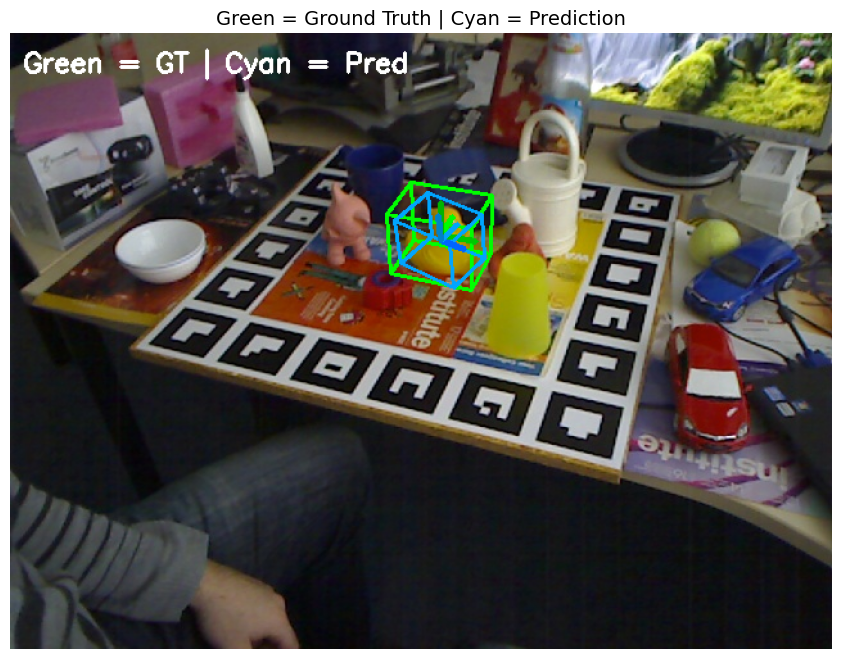

In [ ]:
import importlib, visualize
importlib.reload(visualize)
from visualize import visualize_predictions

visualize_predictions(
    cam_k=cam_k_vis,
    image_path="./datasets/linemod/DenseFusion/Linemod_preprocessed/data/09/rgb/0060.png",
    pose_checkpoint="./checkpoints/best_pose_model_with_stats.pt",
    device="cuda"
)

### Testing YOLO + ResNet Pipeline